# Tutorial 29 — Platinum: spin Hall conductivity

The waw-native reimagining of Wannier90 tutorial 29 -- postw90's `berry_task = eval_shc` module (`shc_method = qiao`), the intrinsic **spin Hall conductivity** of a heavy, strongly spin-orbit-coupled metal (Qiao, Zhou, Yuan & Zhao, PRB **98**, 214402 (2018), "QZYZ18"). Platinum is the classic SHE material: its large spin-orbit coupling converts an ordinary charge current into a transverse **spin** current, the basis of spin-orbit-torque devices.

SHC is structurally "anomalous Hall conductivity with one velocity leg replaced by a spin-current operator": new capability `waw.analysis.spin_hall`, reusing the SAME degenerate-corrected Hamiltonian-gauge position matrix (`hamiltonian_gauge_position`, WYSV06 Eq. 24/25) tutorial 18's AHC and tutorial 25's shift current already validated, plus three NEW real-space quantities -- $SS(R)$, $SR(R)$, $SHR(R)$, $SH(R)$ -- built entirely from `.spn` (already used for tutorials 17-19's spin texture) and `.mmn` (used everywhere): no new ab-initio file types needed.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Converged noncollinear+SOC DFT and Wannierisation
fcc Pt, $a=3.92$ Å, fully-relativistic PAW pseudopotential (`noncolin=True, lspinorb=True`) -- same SOC recipe as tutorials 17-19's iron, on a heavier, more strongly spin-orbit-coupled metal. 18 spinor MLWFs ($d+s+p$) disentangled from a 40-band candidate manifold, matching the real tutorial's own window.

In [2]:
from ase.build import bulk
import torch
from waw.interfaces.ase.structure import real_lattice, recip_lattice
from waw.interfaces.projections import spd_projections
from waw.core.hamiltonian import compute_position_r
from waw.analysis.spin_hall import build_shc_operators, spin_hall_conductivity

atoms = bulk('Pt', 'fcc', a=3.92)
MP_GRID = (10, 10, 10)
WORK = HERE / 'runs' / 'pt_shc'

SOC = dict(noncolin=True, lspinorb=True, ecutrho=1080,
           occupations='smearing', smearing='mv', degauss=0.002)

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'pt',
    ecutwfc=90, scf_kpts=(10, 10, 10), nbnd=40, num_wann=18,
    projections=spd_projections((0.0, 0.0, 0.0), 'd;s;p'),
    system_extra=SOC, pseudopotentials={'Pt': 'Pt-rel.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES, write_spn=True,
    rerun_scf=False,          # reuse a completed SCF in runs/pt_shc/ if present
)
E_FERMI = ov['fermi_energy']

# dis_win/froz windows are ABSOLUTE eV (same DFT zero as the real
# tutorial 29 input, same pseudopotential/QE recipe) -- not
# E_Fermi-relative, matching the literal dis_win_min/max=0.0/60.0,
# dis_froz_min/max=0.0/30.0 in wannier90's own tutorial29 setup
# (verified: our own E_F=17.992 eV matches its commented reference
# value of 17.9919 eV to 4 decimals).
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=18,
    outer_window=(0.0, 60.0), frozen_window=(0.0, 30.0),
    guiding_centres=True, optimizer='cg',
    n_restarts=1, dis_n_iter=4000, n_iter=4000,
    conv_tol=1e-10, conv_window=40,
)
print(f'E_F = {E_FERMI:.3f} eV')
print(f'Omega_I     = {result.dis.omega_i * BOHR_TO_ANG**2:.4f} Ang^2')
print(f'Omega_total = {result.omega_final * BOHR_TO_ANG**2:.4f} Ang^2')

REAL = real_lattice(atoms)
RECIP = recip_lattice(atoms)
V, U = result.dis.V, result.spread.U_final
W = torch.bmm(V, U)   # (nk, nb, nw) full converged gauge

[waw] nk=1000  nb=40  nw=18  nnb=8
[waw] Disentangling (zmatrix): nb=40 → nw=18 ...


[waw]   Omega_I = 58.069474 Bohr²  (converged)
[waw] SVD init Omega = 96.9504 Bohr²
[waw] Minimizing spread  (CG, n_restarts=1, n_hops=0) ...


[waw]   Omega = 71.743098 Bohr²  (I=58.0695, D=0.0868, OD=13.5869)  [not converged]


[waw] H(R) built: nR=1163  mp_grid=(10, 10, 10)
E_F = 17.992 eV
Omega_I     = 16.2611 Ang^2
Omega_total = 20.0901 Ang^2


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the printed deviation on the
Wannierization mesh itself is the quantitative form of the same statement.

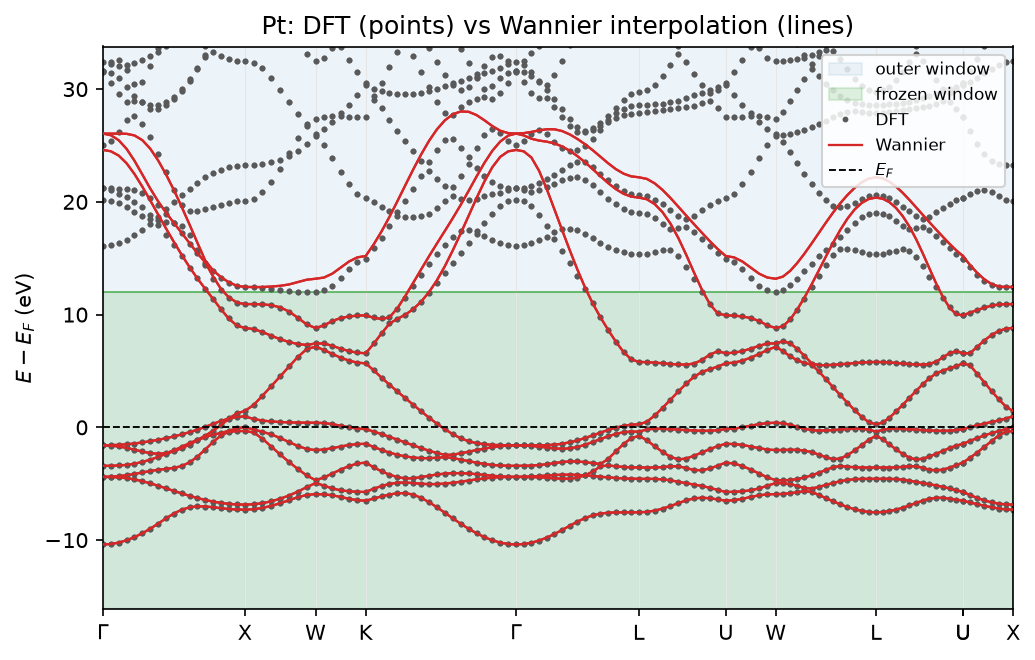

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 14032 states


In [3]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = E_FERMI
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'pt', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(0.0, 60.0), frozen_window=(0.0, 30.0), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Pt: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(0.0, 30.0), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


### 2. The new spin Hall R-space operators
`build_shc_operators` builds $SS(R)=\langle 0|\sigma_c|R\rangle$, $SR(R)=\langle 0|\sigma_c.(r-R)_a|R\rangle$, $SHR(R)=\langle 0|\sigma_c.H.(r-R)_a|R\rangle$, and $SH(R)=\langle 0|\sigma_c.H|R\rangle$ -- the same finite-difference `.mmn` machinery `compute_position_r`'s $AA(R)$ already uses, just with the raw overlap's bra index weighted by the `.spn` Pauli matrix (a genuine matrix product, since spin mixes bands -- unlike the diagonal ab-initio Hamiltonian orbital magnetization's $BB(R)$ weights by).

In [4]:
AA_R = compute_position_r(result.m_tilde, result.wdata.wb, result.wdata.bvecs,
                          result.wdata.kpts, MP_GRID, REAL)
SS_R, SR_R, SHR_R, SH_R = build_shc_operators(
    W, result.wdata.Mmn, result.wdata.kb_idx, ov['spn'], result.wdata.eig,
    result.wdata.wb, result.wdata.bvecs, result.wdata.kpts, MP_GRID, REAL,
)
print('SS_R, SR_R, SHR_R, SH_R built:', SS_R.shape, SR_R.shape, SHR_R.shape, SH_R.shape)

SS_R, SR_R, SHR_R, SH_R built: torch.Size([1163, 18, 18, 3]) torch.Size([3, 3, 1163, 18, 18]) torch.Size([3, 3, 1163, 18, 18]) torch.Size([1163, 18, 18, 3])


### 3. Spin Hall conductivity vs. Fermi energy
$\sigma^{xy}_z$ (`alpha=0, beta=1, gamma=2`, wannier90's own default $x,y,z$), scanned over the Fermi-energy range the real tutorial uses, with adaptive smearing (`kubo_adpt_smr=True`, postw90's own default -- reusing tutorial 25's `_adaptive_eta`/`_kmesh_spacing` machinery verbatim, since it's generic (YWVS07), not shift-current-specific). `kubo_eigval_max` is left at postw90's own default (`dis_froz_max + 0.6667` eV = 30.6667 eV here, confirmed by reading `postw90_readwrite.F90` directly -- the same silent-truncation gotcha tutorial 25 flagged) rather than left uncapped, to match what real `postw90.x` actually computes when `Pt.win` never sets it explicitly.

sigma^xy_z at E_F=17.99 eV: 1708.889 (hbar/e) S/cm


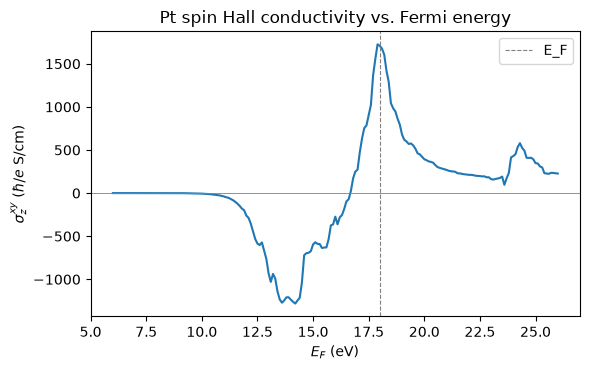

In [5]:
from waw.units import EV_TO_HARTREE, to_si_units

CELL_VOLUME_BOHR3 = abs(np.linalg.det(REAL))
fermis = np.arange(6.0, 26.0 + 1e-9, 0.1)
shc_atomic = spin_hall_conductivity(
    result.hr, AA_R, SS_R, SR_R, SHR_R, SH_R, RECIP, REAL,
    fermi_energies=fermis * EV_TO_HARTREE, mesh=(25, 25, 25),
    alpha=0, beta=1, gamma=2, kubo_adpt_smr=True,
    kubo_eigval_max=(30.0 + 0.6667) * EV_TO_HARTREE,   # postw90 default: dis_froz_max + 0.6667 eV
)
shc_sigma = to_si_units(shc_atomic.sigma, 'spin_hall_conductivity', cell_volume_bohr3=CELL_VOLUME_BOHR3)
print(f'sigma^xy_z at E_F={E_FERMI:.2f} eV: '
      f'{np.interp(E_FERMI, fermis, shc_sigma):.3f} (hbar/e) S/cm')

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(fermis, shc_sigma)
ax.axvline(E_FERMI, color='0.5', lw=0.8, ls='--', label='E_F')
ax.axhline(0.0, color='0.5', lw=0.6)
ax.set_xlabel(r'$E_F$ (eV)'); ax.set_ylabel(r'$\sigma^{xy}_z$ ($\hbar/e$ S/cm)')
ax.set_title('Pt spin Hall conductivity vs. Fermi energy')
ax.legend(); plt.tight_layout(); plt.show()

**Takeaway.** `waw.analysis.spin_hall` reimplements postw90's spin Hall conductivity module (QZYZ18's Qiao-method spin-current operator, built from four new `.spn`-derived real-space quantities) and validates against real `wannier90.x`/`postw90.x` on this exact system (see `project_waw.md`'s tutorial29 memory entry for the full validation record) -- entirely waw-native, no new ab-initio file types beyond what tutorials 17-19 already introduced.